<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-22</br>
</div>

</br>

# 학습 내용
>이번 장에서는 <strong>ResNet-18 전이학습(Transfer Learning with ResNet-18)</strong>에 대해 학습합니다.</br></br>
>생성 데이터로 ResNet-18을 학습하고, Knowledge Distillation 개념을 학습해봅시다.</br></br>

<div style="text-align:center">

</div>

</br>

# ResNet-18 전이학습
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">생성된 이미지 데이터</mark>로 ResNet-18을 전이학습하여 커스텀 분류기를 구축합니다.</br></br>

> ResNet-50은 약 2,500만 개의 파라미터를 갖지만, <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">ResNet-18은 약 1,100만 개</mark>로 절반 이하입니다.</br></br>
> 파라미터 수가 적으면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">학습 속도가 빠르고 GPU 메모리 사용량이 낮아</mark> 소규모 프로젝트와 실험에 적합합니다.</br></br>
> ImageNet으로 사전학습된 ResNet-18은 이미 에지, 텍스처, 형태 등 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">범용적인 시각 특징</mark>을 학습한 상태이므로, 분류 헤드만 교체하면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">소량의 데이터만으로도 높은 성능</mark>을 달성할 수 있어 데이터 수집 비용을 크게 절감합니다.</br>

In [89]:
# TODO 0: 필요한 라이브러리를 임포트하고, 학습에 사용할 장치를 설정해봅시다.

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet18, resnet50, ResNet18_Weights, ResNet50_Weights
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"사용 장치: {device}")

# matplotlib 한글 폰트 설정
import platform
if platform.system() == "Darwin":  # macOS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

사용 장치: mps


</br>

## 합성 데이터 생성 (Synthetic Data Generation)
> 실제 데이터 수집이 어렵거나 비용이 높을 때, <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">생성 모델을 활용하여 합성 데이터(Synthetic Data)를 만들어 학습에 활용</mark>할 수 있습니다.</br></br>
> 이번 실습에서는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Stable Diffusion</mark> 파이프라인으로 5개 클래스(cat, dog, car, airplane, flower)의 이미지를 생성하고, 이를 학습/테스트 데이터셋으로 구성합니다.</br></br>

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">폴더 구조</th>
      <th style="text-align:center">설명</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center"><code>data/train/{클래스명}/</code></td><td style="text-align:center">학습용 이미지 (클래스별 2장)</td></tr>
    <tr><td style="text-align:center"><code>data/test/{클래스명}/</code></td><td style="text-align:center">테스트용 이미지 (클래스별 1장)</td></tr>
  </tbody>
</table>

> `ImageFolder`는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">폴더 이름을 클래스 라벨로 자동 인식</mark>합니다. 위 구조로 저장하면 별도의 라벨 파일 없이도 데이터셋을 구성할 수 있습니다.</br></br>

In [90]:
# TODO 1: StableDiffusionPipeline을 로드해봅시다. (모델: "runwayml/stable-diffusion-v1-5", dtype: float16)

from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

print("파이프라인 로드 완료!")

Loading weights: 100%|██████████| 396/396 [00:00<00:00, 9111.85it/s]
StableDiffusionSafetyChecker LOAD REPORT from: /Users/sahong.pak/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...:  29%|██▊       | 2/7 [00:00<00:00,  6.54it/s]You are using a model of type `clip_text_model` to instantiate a model of type `clip`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is c

파이프라인 로드 완료!


In [91]:
# TODO 2: 5개 클래스에 대한 프롬프트를 정의해봅시다.

class_prompts = {
    "cat": "a photo of a cute domestic cat sitting, high quality, detailed",
    "dog": "a photo of a golden retriever dog sitting, high quality, detailed",
    "car": "a photo of a red sports car on a road, high quality, detailed",
    "airplane": "a photo of a commercial airplane flying in the sky, high quality, detailed",
    "flower": "a photo of a beautiful sunflower in a garden, high quality, detailed",
}

print(f"클래스 수: {len(class_prompts)}")
for cls, prompt in class_prompts.items():
    print(f"  {cls}: {prompt[:50]}...")

클래스 수: 5
  cat: a photo of a cute domestic cat sitting, high quali...
  dog: a photo of a golden retriever dog sitting, high qu...
  car: a photo of a red sports car on a road, high qualit...
  airplane: a photo of a commercial airplane flying in the sky...
  flower: a photo of a beautiful sunflower in a garden, high...


In [92]:
# TODO 3: 각 클래스별로 train 10장, test 3장의 이미지를 생성하여 저장해봅시다.

train_seeds = list(range(100, 110))  # 학습용 시드 10개 → 클래스당 10장
test_seeds = [200, 201, 202]         # 테스트용 시드 3개 → 클래스당 3장

for split, seeds in [("train", train_seeds), ("test", test_seeds)]:
    for cls, prompt in class_prompts.items():
        os.makedirs(f"data/{split}/{cls}", exist_ok=True)  # 디렉토리 생성 (없으면)
        for i, seed in enumerate(seeds):
            save_path = f"data/{split}/{cls}/{cls}_{split}_{i}.png"
            if os.path.exists(save_path):  # 이미 생성된 이미지는 건너뛰기
                print(f"[{split}] {cls}_{i} 이미 존재, 건너뜀")
                continue
            # TODO 3-1: 시드를 고정하여 재현 가능한 Generator를 생성해봅시다.
            generator = torch.Generator(device=device).manual_seed(seed)  # 시드 고정 → 재현 가능
            # TODO 3-2: 파이프라인으로 이미지를 생성해봅시다.
            result = pipe(
                prompt=prompt,
                guidance_scale=7.5,     # 프롬프트 충실도
                num_inference_steps=30, # 디노이징 단계 수
                height=512,
                width=512,
                generator=generator,
            )
            # TODO 3-3: 생성된 이미지를 저장해봅시다.
            image = result.images[0]  # 생성된 이미지 추출
            image.save(save_path)
            print(f"[{split}] {cls}_{i} 저장 완료 (seed={seed})")

print(f"\n데이터 생성 완료! train: {len(train_seeds)}장/클래스, test: {len(test_seeds)}장/클래스")

100%|██████████| 30/30 [00:06<00:00,  4.73it/s]


[train] cat_0 저장 완료 (seed=100)


100%|██████████| 30/30 [00:06<00:00,  4.73it/s]


[train] cat_1 저장 완료 (seed=101)


100%|██████████| 30/30 [00:06<00:00,  4.66it/s]


[train] cat_2 저장 완료 (seed=102)


100%|██████████| 30/30 [00:06<00:00,  4.59it/s]


[train] cat_3 저장 완료 (seed=103)


100%|██████████| 30/30 [00:06<00:00,  4.55it/s]


[train] cat_4 저장 완료 (seed=104)


100%|██████████| 30/30 [00:06<00:00,  4.50it/s]


[train] cat_5 저장 완료 (seed=105)


100%|██████████| 30/30 [00:07<00:00,  4.04it/s]


[train] cat_6 저장 완료 (seed=106)


100%|██████████| 30/30 [00:08<00:00,  3.64it/s]


[train] cat_7 저장 완료 (seed=107)


100%|██████████| 30/30 [00:08<00:00,  3.56it/s]


[train] cat_8 저장 완료 (seed=108)


100%|██████████| 30/30 [00:08<00:00,  3.52it/s]


[train] cat_9 저장 완료 (seed=109)


100%|██████████| 30/30 [00:09<00:00,  3.28it/s]


[train] dog_0 저장 완료 (seed=100)


100%|██████████| 30/30 [00:08<00:00,  3.35it/s]


[train] dog_1 저장 완료 (seed=101)


100%|██████████| 30/30 [00:08<00:00,  3.37it/s]


[train] dog_2 저장 완료 (seed=102)


100%|██████████| 30/30 [00:08<00:00,  3.51it/s]


[train] dog_3 저장 완료 (seed=103)


100%|██████████| 30/30 [00:08<00:00,  3.42it/s]


[train] dog_4 저장 완료 (seed=104)


100%|██████████| 30/30 [00:08<00:00,  3.57it/s]


[train] dog_5 저장 완료 (seed=105)


100%|██████████| 30/30 [00:08<00:00,  3.46it/s]


[train] dog_6 저장 완료 (seed=106)


100%|██████████| 30/30 [00:08<00:00,  3.51it/s]


[train] dog_7 저장 완료 (seed=107)


100%|██████████| 30/30 [00:08<00:00,  3.48it/s]


[train] dog_8 저장 완료 (seed=108)


100%|██████████| 30/30 [00:08<00:00,  3.46it/s]


[train] dog_9 저장 완료 (seed=109)


100%|██████████| 30/30 [00:08<00:00,  3.42it/s]


[train] car_0 저장 완료 (seed=100)


100%|██████████| 30/30 [00:08<00:00,  3.37it/s]


[train] car_1 저장 완료 (seed=101)


100%|██████████| 30/30 [00:08<00:00,  3.59it/s]


[train] car_2 저장 완료 (seed=102)


100%|██████████| 30/30 [00:08<00:00,  3.63it/s]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


[train] car_3 저장 완료 (seed=103)


100%|██████████| 30/30 [00:08<00:00,  3.35it/s]


[train] car_4 저장 완료 (seed=104)


100%|██████████| 30/30 [00:09<00:00,  3.25it/s]


[train] car_5 저장 완료 (seed=105)


100%|██████████| 30/30 [00:09<00:00,  3.27it/s]


[train] car_6 저장 완료 (seed=106)


100%|██████████| 30/30 [00:09<00:00,  3.17it/s]


[train] car_7 저장 완료 (seed=107)


100%|██████████| 30/30 [00:09<00:00,  3.11it/s]


[train] car_8 저장 완료 (seed=108)


100%|██████████| 30/30 [00:10<00:00,  2.91it/s]


[train] car_9 저장 완료 (seed=109)


100%|██████████| 30/30 [00:09<00:00,  3.09it/s]


[train] airplane_0 저장 완료 (seed=100)


100%|██████████| 30/30 [00:09<00:00,  3.03it/s]


[train] airplane_1 저장 완료 (seed=101)


100%|██████████| 30/30 [00:10<00:00,  2.91it/s]


[train] airplane_2 저장 완료 (seed=102)


100%|██████████| 30/30 [00:10<00:00,  2.87it/s]


[train] airplane_3 저장 완료 (seed=103)


100%|██████████| 30/30 [00:10<00:00,  2.84it/s]


[train] airplane_4 저장 완료 (seed=104)


100%|██████████| 30/30 [00:10<00:00,  2.85it/s]


[train] airplane_5 저장 완료 (seed=105)


100%|██████████| 30/30 [00:10<00:00,  2.93it/s]


[train] airplane_6 저장 완료 (seed=106)


100%|██████████| 30/30 [00:09<00:00,  3.01it/s]


[train] airplane_7 저장 완료 (seed=107)


100%|██████████| 30/30 [00:09<00:00,  3.02it/s]


[train] airplane_8 저장 완료 (seed=108)


100%|██████████| 30/30 [00:10<00:00,  2.99it/s]


[train] airplane_9 저장 완료 (seed=109)


100%|██████████| 30/30 [00:09<00:00,  3.01it/s]


[train] flower_0 저장 완료 (seed=100)


100%|██████████| 30/30 [00:09<00:00,  3.04it/s]


[train] flower_1 저장 완료 (seed=101)


100%|██████████| 30/30 [00:09<00:00,  3.08it/s]


[train] flower_2 저장 완료 (seed=102)


100%|██████████| 30/30 [00:09<00:00,  3.07it/s]


[train] flower_3 저장 완료 (seed=103)


100%|██████████| 30/30 [00:09<00:00,  3.13it/s]


[train] flower_4 저장 완료 (seed=104)


100%|██████████| 30/30 [00:09<00:00,  3.08it/s]


[train] flower_5 저장 완료 (seed=105)


100%|██████████| 30/30 [00:09<00:00,  3.18it/s]


[train] flower_6 저장 완료 (seed=106)


100%|██████████| 30/30 [00:09<00:00,  3.16it/s]


[train] flower_7 저장 완료 (seed=107)


100%|██████████| 30/30 [00:09<00:00,  3.17it/s]


[train] flower_8 저장 완료 (seed=108)


100%|██████████| 30/30 [00:09<00:00,  3.20it/s]


[train] flower_9 저장 완료 (seed=109)


100%|██████████| 30/30 [00:09<00:00,  3.17it/s]


[test] cat_0 저장 완료 (seed=200)


100%|██████████| 30/30 [00:09<00:00,  3.22it/s]


[test] cat_1 저장 완료 (seed=201)


100%|██████████| 30/30 [00:09<00:00,  3.21it/s]


[test] cat_2 저장 완료 (seed=202)


100%|██████████| 30/30 [00:09<00:00,  3.21it/s]


[test] dog_0 저장 완료 (seed=200)


100%|██████████| 30/30 [00:09<00:00,  3.25it/s]


[test] dog_1 저장 완료 (seed=201)


100%|██████████| 30/30 [00:09<00:00,  3.25it/s]


[test] dog_2 저장 완료 (seed=202)


100%|██████████| 30/30 [00:09<00:00,  3.26it/s]


[test] car_0 저장 완료 (seed=200)


100%|██████████| 30/30 [00:09<00:00,  3.21it/s]


[test] car_1 저장 완료 (seed=201)


100%|██████████| 30/30 [00:09<00:00,  3.29it/s]


[test] car_2 저장 완료 (seed=202)


100%|██████████| 30/30 [00:09<00:00,  3.28it/s]


[test] airplane_0 저장 완료 (seed=200)


100%|██████████| 30/30 [00:09<00:00,  3.30it/s]


[test] airplane_1 저장 완료 (seed=201)


100%|██████████| 30/30 [00:09<00:00,  3.28it/s]


[test] airplane_2 저장 완료 (seed=202)


100%|██████████| 30/30 [00:08<00:00,  3.34it/s]


[test] flower_0 저장 완료 (seed=200)


100%|██████████| 30/30 [00:09<00:00,  3.28it/s]


[test] flower_1 저장 완료 (seed=201)


100%|██████████| 30/30 [00:09<00:00,  3.31it/s]


[test] flower_2 저장 완료 (seed=202)

데이터 생성 완료! train: 10장/클래스, test: 3장/클래스


In [93]:
# TODO 4: 학습용 transforms를 정의해봅시다. (RandomResizedCrop, RandomHorizontalFlip, ToTensor, Normalize)

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [94]:
# TODO 5: 테스트용 transforms를 정의해봅시다. (Resize, ToTensor, Normalize)

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [95]:
# TODO 6: ImageFolder로 데이터셋을 생성해봅시다.

train_dataset = ImageFolder("data/train", transform=train_transforms)
test_dataset = ImageFolder("data/test", transform=test_transforms)

print(f"학습 이미지: {len(train_dataset)}장, 테스트 이미지: {len(test_dataset)}장")
print(f"클래스: {train_dataset.classes}")
print(f"클래스→인덱스: {train_dataset.class_to_idx}")

학습 이미지: 50장, 테스트 이미지: 15장
클래스: ['airplane', 'car', 'cat', 'dog', 'flower']
클래스→인덱스: {'airplane': 0, 'car': 1, 'cat': 2, 'dog': 3, 'flower': 4}


💡`ImageFolder`란?
> 폴더 구조를 그대로 데이터셋으로 변환해주는 유틸리티입니다.</br></br>
> `data/train/cat/`, `data/train/dog/` 처럼 폴더명이 곧 클래스명이 됩니다.</br></br>
> 별도의 라벨 파일 없이 폴더만 정리하면 바로 학습에 사용할 수 있습니다.</br></br>

In [96]:
# TODO 7: DataLoader를 생성해봅시다. (batch_size=4)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"학습 배치 수: {len(train_loader)}, 테스트 배치 수: {len(test_loader)}")

학습 배치 수: 13, 테스트 배치 수: 4


💡ImageFolder 사용 팁
> `ImageFolder`는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">폴더명을 알파벳 순으로 정렬</mark>하여 클래스 인덱스를 자동 부여합니다.</br>
> 예: airplane=0, car=1, cat=2, dog=3, flower=4</br>
> 학습용 transforms에는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">RandomResizedCrop, RandomHorizontalFlip</mark> 등 데이터 증강을 적용하고, 테스트용에는 단순 Resize만 적용합니다.</br></br>

</br>

## 모델 설정 (Freeze + fc 교체)

In [97]:
# TODO 8: ResNet18 사전학습 모델을 로드해봅시다.

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

print(f"전체 파라미터: {sum(p.numel() for p in model.parameters()):,}")

전체 파라미터: 11,689,512


💡`from_pretrained` / `weights=` 란?
> 다른 사람이 대규모 데이터로 미리 학습해둔 가중치를 불러오는 것입니다.</br></br>
> 직접 처음부터 학습하면 수일~수주가 걸리지만, 사전학습 가중치를 재활용하면 소량의 데이터로도 빠르게 좋은 성능을 얻을 수 있습니다.</br></br>

In [98]:
# TODO 9: 모든 파라미터를 동결(freeze)해봅시다.

for param in model.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 가능 파라미터: {trainable:,}")

학습 가능 파라미터: 0


In [99]:
# TODO 10: fc 레이어를 5개 클래스에 맞게 교체해봅시다.

num_classes = 5
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 파라미터: {trainable:,} (fc: {model.fc.in_features} → {num_classes})")

학습 파라미터: 2,565 (fc: 512 → 5)


</br>

## 학습 설정

In [100]:
# TODO 11: fc 레이어의 파라미터만 학습하도록 옵티마이저를 설정해봅시다.

optimizer = optim.SGD(
    model.fc.parameters(),     # fc만 학습
    lr=0.01,
    momentum=0.9
)

print(f"옵티마이저: SGD (lr=0.01, momentum=0.9)")

옵티마이저: SGD (lr=0.01, momentum=0.9)


In [101]:
# TODO 12: 분류용 손실 함수와 학습 에폭 수를 정의해봅시다.

cross_entropy = nn.CrossEntropyLoss()
epochs = 3

print(f"손실 함수: CrossEntropyLoss")
print(f"에폭 수: {epochs}")

손실 함수: CrossEntropyLoss
에폭 수: 3


</br>

## 학습 루프

In [102]:
# TODO 13: 에폭만큼 반복하며 학습 데이터로 모델을 학습시키고, 테스트 데이터로 정확도를 평가하여 에폭별 손실과 정확도를 출력해봅시다.

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # TODO 13-1: 이전 배치의 기울기가 누적되지 않도록 초기화해봅시다.
        optimizer.zero_grad()  # 이전 배치의 기울기 초기화
        # TODO 13-2: 이미지를 모델에 통과시켜 순전파를 수행해봅시다.
        outputs = model(images)  # 순전파: 입력 → 레이어 통과 → 예측값
        # TODO 13-3: 예측값(outputs)과 정답(labels)의 손실을 계산해봅시다.
        loss = cross_entropy(outputs, labels)  # 예측 vs 정답 비교 → 오차 측정
        # TODO 13-4: 손실을 기준으로 각 파라미터의 기울기를 계산(역전파)해봅시다.
        loss.backward()  # 역전파: 각 파라미터의 기울기 계산
        # TODO 13-5: 계산된 기울기로 파라미터를 업데이트해봅시다.
        optimizer.step()  # 기울기 방향으로 파라미터 업데이트
        running_loss += loss.item() * labels.size(0)  # 배치 평균 손실 × 샘플 수 = 배치 총 손실

    # TODO 13-6: 검증을 위해 모델을 평가 모드로 전환해봅시다.
    model.eval()
    correct_count, total_count = 0, 0
    # TODO 13-7: 기울기 계산 없이 테스트 데이터로 예측해봅시다.
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # 순전파: 입력 → 레이어 통과 → 예측값
            # TODO 13-8: 가장 높은 확률의 클래스를 예측값으로 선택해봅시다.
            _, predicted = outputs.max(1)
            correct_count += (predicted == labels).sum().item()
            total_count += labels.size(0)

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Test Acc={correct_count/total_count:.2%}")

Epoch 1: Loss=8.1493, Test Acc=86.67%
Epoch 2: Loss=4.6666, Test Acc=100.00%
Epoch 3: Loss=3.8594, Test Acc=100.00%


</br>

## 모델 평가 및 시각화

In [103]:
# TODO 14: 역정규화 함수를 정의해봅시다.

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def denormalize(img_tensor, mean=mean, std=std):
    """정규화된 이미지 텐서를 [0, 1] 범위로 복원합니다."""
    mean_t = torch.tensor(mean).view(-1, 1, 1)
    std_t = torch.tensor(std).view(-1, 1, 1)
    image = img_tensor.cpu() * std_t + mean_t
    return image.clamp(0, 1)

print("역정규화 함수 정의 완료")

역정규화 함수 정의 완료


In [104]:
# TODO 15: 테스트 데이터에 대해 예측을 수행하고 결과를 수집해봅시다.

model.eval()
class_names = test_dataset.classes
correct_count, total_count = 0, 0
images_to_show, preds_to_show, labels_to_show = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct_count += (predicted == labels).sum().item()
        total_count += labels.size(0)

        for image, prediction, label in zip(images, predicted, labels):
            images_to_show.append(denormalize(image))
            preds_to_show.append(class_names[prediction])
            labels_to_show.append(class_names[label])

print(f"테스트 정확도: {correct_count/total_count:.2%}")

테스트 정확도: 100.00%


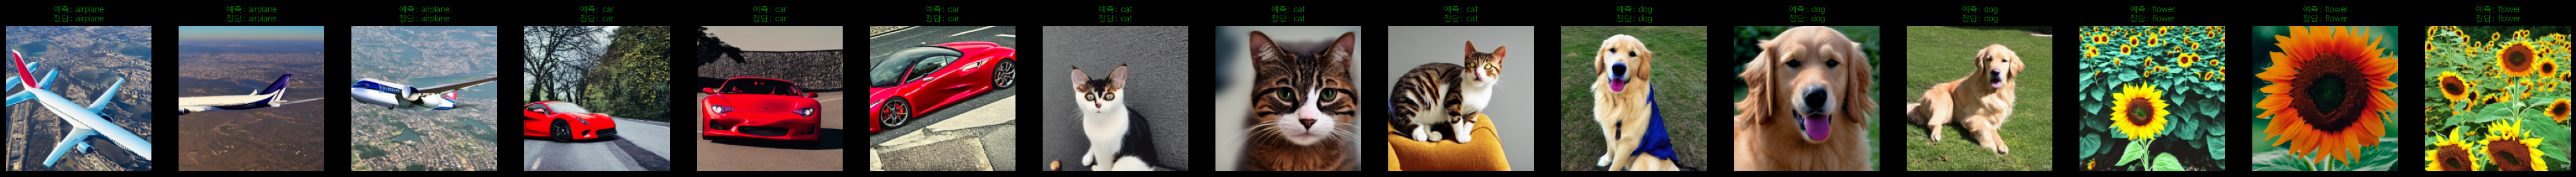

In [105]:
# TODO 16: 예측 결과를 시각화해봅시다.

n = len(images_to_show)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
if n == 1:
    axes = [axes]
for i, (image, prediction, label) in enumerate(zip(images_to_show, preds_to_show, labels_to_show)):
    axes[i].imshow(image.permute(1, 2, 0).numpy())
    color = "green" if prediction == label else "red"
    axes[i].set_title(f"예측: {prediction}\n정답: {label}", color=color, fontsize=10)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

💡역정규화 (Denormalization)
> 모델에 입력하기 전 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">ImageNet 평균/표준편차로 정규화</mark>한 이미지는 사람이 볼 수 없는 값 범위를 갖습니다.</br>
> 시각화할 때는 `image * std + mean`으로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">원래 [0, 1] 범위로 복원</mark>해야 올바른 색상이 표시됩니다.</br></br>

</br>

# Knowledge Distillation (지식 증류)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">큰 모델(Teacher)의 지식을 작은 모델(Student)에 전달</mark>하는 모델 압축 기법입니다.</br></br>

<div style="text-align:center">

</div>

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">구성요소</th>
      <th>설명</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">Teacher</td><td>큰 사전학습 모델 (성능 높음)</td></tr>
    <tr><td style="text-align:center">Student</td><td>작은 모델 (경량, 배포용)</td></tr>
    <tr><td style="text-align:center">Soft Labels</td><td>Teacher의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">확률 분포</mark> (temperature 적용)</td></tr>
    <tr><td style="text-align:center">KD Loss</td><td>Soft Labels와 Student 출력 간 KL Divergence</td></tr>
  </tbody>
</table>

<div style="text-align:center">

</div>

In [106]:
# TODO 17: Teacher 모델의 logits에 Temperature를 적용하여 Soft Labels을 계산하고, Hard Labels과 확률 분포가 어떻게 달라지는지 비교해봅시다.

# Temperature Scaling 예시
teacher_logits = torch.tensor([5.0, 2.0, 1.0])
temperature = 3.0

hard_labels = F.softmax(teacher_logits, dim=0)
soft_labels = F.softmax(teacher_logits / temperature, dim=0)

print(f"Hard Labels (T=1): {hard_labels.data.round(decimals=3)}")
print(f"Soft Labels (T={int(temperature)}): {soft_labels.data.round(decimals=3)}")

Hard Labels (T=1): tensor([0.9360, 0.0470, 0.0170])
Soft Labels (T=3): tensor([0.6130, 0.2250, 0.1620])


<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">클래스</th>
      <th style="text-align:center">Hard Label (T=1)</th>
      <th style="text-align:center">Soft Label (T=3)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">Class 0</td><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">0.936</mark></td><td style="text-align:center">0.592</td></tr>
    <tr><td style="text-align:center">Class 1</td><td style="text-align:center">0.047</td><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">0.243</mark></td></tr>
    <tr><td style="text-align:center">Class 2</td><td style="text-align:center">0.017</td><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">0.165</mark></td></tr>
  </tbody>
</table>

💡Temperature의 역할
> Temperature > 1로 설정하면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">확률 분포가 부드러워져</mark> 클래스 간 관계 정보가 전달됩니다.</br>
> 예: [0.9, 0.05, 0.05] → [0.6, 0.2, 0.2] (더 많은 정보 포함)

💡왜 KD를 사용하는가?
> Hard Label(정답 라벨)보다 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Soft Label이 더 풍부한 정보</mark>를 포함합니다.</br>
> "고양이와 호랑이는 비슷하다"는 관계 정보가 Soft Label에 암묵적으로 담깁니다.</br></br>

</br>

## Knowledge Distillation 구현
> 앞에서 학습한 개념을 바탕으로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Teacher-Student 구조의 Knowledge Distillation</mark>을 직접 구현합니다.</br></br>
> **KD Loss 공식:**</br>
> `KD_Loss = alpha * temperature² * KL_Divergence(student_soft, teacher_soft) + (1 - alpha) * CE_Loss(student_hard, true_label)`</br></br>
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Teacher(ResNet-50)</mark>의 soft label을 활용하여 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Student(ResNet-18)</mark>를 학습시키고, 기본 학습(TODO 5)과 성능을 비교합니다.</br></br>

<div style="text-align:center">

</div>

In [107]:
# TODO 18: ResNet-50 Teacher 모델을 로드하고 동결해봅시다.

teacher_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
for param in teacher_model.parameters():
    param.requires_grad = False

print(f"Teacher 파라미터: {sum(p.numel() for p in teacher_model.parameters()):,}")

Teacher 파라미터: 25,557,032


In [108]:
# TODO 19: Teacher의 fc 레이어를 교체하고 학습 설정을 정의해봅시다.

teacher_model.fc = nn.Linear(teacher_model.fc.in_features, num_classes)
teacher_model = teacher_model.to(device)

teacher_optimizer = optim.SGD(teacher_model.fc.parameters(), lr=0.01, momentum=0.9)
teacher_cross_entropy = nn.CrossEntropyLoss()
teacher_epochs = 5

print(f"Teacher fc: {teacher_model.fc.in_features} → {num_classes}")

Teacher fc: 2048 → 5


In [109]:
# TODO 20: Teacher 모델을 합성 데이터로 5 에폭 학습시켜봅시다.

for epoch in range(teacher_epochs):
    teacher_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        teacher_optimizer.zero_grad()
        outputs = teacher_model(images)
        loss = teacher_cross_entropy(outputs, labels)
        loss.backward()  # 역전파: 각 파라미터의 기울기 계산
        teacher_optimizer.step()
        running_loss += loss.item() * labels.size(0)  # 배치 평균 손실 × 샘플 수 = 배치 총 손실

    print(f"Teacher Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}")

Teacher Epoch 1: Loss=5.3953
Teacher Epoch 2: Loss=2.2834
Teacher Epoch 3: Loss=1.3821
Teacher Epoch 4: Loss=0.6257
Teacher Epoch 5: Loss=0.8952


In [110]:
# TODO 21: Teacher 모델의 테스트 정확도를 평가해봅시다.

teacher_model.eval()
correct_count, total_count = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = teacher_model(images)
        _, predicted = outputs.max(1)
        correct_count += (predicted == labels).sum().item()
        total_count += labels.size(0)
print(f"Teacher 테스트 정확도: {correct_count/total_count:.2%}")

Teacher 테스트 정확도: 100.00%


💡Teacher 모델 선택
> Teacher 모델은 Student보다 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">더 크고 성능이 높은 모델</mark>을 사용합니다.</br>
> ResNet-50(약 2,500만 파라미터)은 ResNet-18(약 1,100만 파라미터)보다 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">2배 이상 큰 모델</mark>이므로 Teacher로 적합합니다.</br></br>

In [111]:
# TODO 22: KD 하이퍼파라미터를 정의해봅시다. (Temperature, alpha)

temperature = 4.0  # Temperature: 높을수록 확률 분포가 부드러워짐
alpha = 0.7        # KL Loss 비중 (1-alpha는 CE Loss 비중)

print(f"Temperature: {temperature}, alpha: {alpha}")

Temperature: 4.0, alpha: 0.7


💡alpha의 역할
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">alpha</mark>는 두 손실 함수의 비중을 조절하는 하이퍼파라미터입니다.</br></br>
> `KD_Loss = alpha × KL_Loss + (1 - alpha) × CE_Loss`</br></br>
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">KL_Loss</mark>: Teacher(ResNet-50)의 확률 분포를 따라가는 손실 — "고양이와 강아지가 비슷하다" 같은 클래스 간 관계 정보를 전달</br>
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">CE_Loss</mark>: 실제 정답 라벨(ground truth)과 비교하는 손실 — "이 이미지는 고양이"라는 사실을 학습</br></br>
> alpha = 0.7이면 Teacher의 클래스 간 관계 정보에 70%, 정답 라벨 맞추기에 30%의 비중을 둡니다.</br>
> Student(ResNet-18)는 이 두 가지를 동시에 학습하여 정답도 맞추면서 Teacher의 지식도 흡수합니다.

In [112]:
# TODO 23: Student 모델(ResNet-18)을 사전학습 가중치로 로드해봅시다.

student_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print(f"Student 전체 파라미터: {sum(p.numel() for p in student_model.parameters()):,}")

Student 전체 파라미터: 11,689,512


In [113]:
# TODO 24: 모든 파라미터를 동결하고 FC 레이어를 교체해봅시다.

for param in student_model.parameters():
    param.requires_grad = False  # 사전학습 가중치 동결
student_model.fc = nn.Linear(student_model.fc.in_features, num_classes)  # 5 클래스용 FC 교체
student_model = student_model.to(device)

print(f"Student 학습 파라미터: {sum(p.numel() for p in student_model.parameters() if p.requires_grad):,}")

Student 학습 파라미터: 2,565


In [114]:
# TODO 25: optimizer와 손실 함수를 정의해봅시다.

student_optimizer = optim.SGD(student_model.fc.parameters(), lr=0.01, momentum=0.9)  # FC만 학습
ce_cross_entropy = nn.CrossEntropyLoss()

In [115]:
# TODO 26: Teacher/Student 모드를 설정하고 에폭 수를 정의해봅시다.

teacher_model.eval()   # Teacher는 eval 모드 고정 (추론만)
student_model.train()  # Student는 학습 모드
kd_epochs = 10

💡log_softmax란?
> `log_softmax(x)` = `log(softmax(x))`를 한 번에 계산하는 함수입니다.</br></br>
> ```
> Teacher: softmax(logits / temperature)     → 일반 확률 [0.6, 0.2, 0.2]
> Student: log_softmax(logits / temperature) → log 확률  [-0.51, -1.61, -1.61]
> ```
> PyTorch의 `F.kl_div()`가 내부적으로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">log 확률</mark>을 입력으로 요구하기 때문에 Student에만 `log_softmax`를 사용합니다.</br></br>
> `softmax` → `log`를 따로 하면 동일하지만, `log_softmax`로 한 번에 하면:</br>
> - <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">수치 안정성</mark>: softmax 결과가 매우 작을 때 log(0) 문제 방지</br>
> - <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">연산 효율</mark>: 두 단계를 하나로 합쳐 더 빠름

In [116]:
# TODO 27: Knowledge Distillation 학습 루프를 구현해봅시다.

for epoch in range(kd_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # TODO 27-1: Teacher의 출력에 Temperature를 적용하여 soft labels을 생성해봅시다.
        with torch.no_grad():
            teacher_logits = teacher_model(images)
            teacher_soft = F.softmax(teacher_logits / temperature, dim=1)

        # TODO 27-2: Student의 출력에 Temperature를 적용하여 log-softmax를 계산해봅시다.
        student_logits = student_model(images)
        student_log_soft = F.log_softmax(student_logits / temperature, dim=1)

        # TODO 27-3: Teacher와 Student의 분포 차이를 KL Divergence로 계산해봅시다. (T² 보정 포함)
        kl_loss = F.kl_div(student_log_soft, teacher_soft, reduction='batchmean') * (temperature ** 2)

        # TODO 27-4: 정답 라벨과의 Cross-Entropy 손실을 계산해봅시다.
        ce_loss = ce_cross_entropy(student_logits, labels)

        # TODO 27-5: KL 손실과 CE 손실을 alpha로 가중합하여 전체 KD 손실을 구해봅시다.
        loss = alpha * kl_loss + (1 - alpha) * ce_loss

        # TODO 27-6: 기울기 초기화 → 역전파 → 파라미터 업데이트를 수행해봅시다.
        student_optimizer.zero_grad()
        loss.backward()  # 역전파: 각 파라미터의 기울기 계산
        student_optimizer.step()

        running_loss += loss.item() * labels.size(0)  # 배치 평균 손실 × 샘플 수 = 배치 총 손실

    print(f"KD Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}")

KD Epoch 1: Loss=10.4472
KD Epoch 2: Loss=9.9166
KD Epoch 3: Loss=18.4668
KD Epoch 4: Loss=18.2727
KD Epoch 5: Loss=15.0527
KD Epoch 6: Loss=8.2760
KD Epoch 7: Loss=6.4778
KD Epoch 8: Loss=18.7691
KD Epoch 9: Loss=17.0176
KD Epoch 10: Loss=12.5304


In [117]:
# TODO 28: KD Student 모델을 테스트 데이터로 평가하고, TODO 13의 기본 학습 결과와 비교해봅시다.

student_model.eval()
correct_count, total_count = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = student_model(images)
        _, predicted = outputs.max(1)
        correct_count += (predicted == labels).sum().item()
        total_count += labels.size(0)

kd_accuracy = correct_count / total_count
print(f"KD Student 테스트 정확도: {kd_accuracy:.2%}")
print(f"\n--- 결과 비교 ---")
print(f"TODO 5 기본 ResNet-18 (CE Loss만 학습): 위 학습 결과 참고")
print(f"TODO 9 KD Student ResNet-18 (Teacher soft label 활용): {kd_accuracy:.2%}")
print(f"\nKnowledge Distillation을 통해 Teacher의 지식이 Student에게 전달되었습니다.")

KD Student 테스트 정확도: 66.67%

--- 결과 비교 ---
TODO 5 기본 ResNet-18 (CE Loss만 학습): 위 학습 결과 참고
TODO 9 KD Student ResNet-18 (Teacher soft label 활용): 66.67%

Knowledge Distillation을 통해 Teacher의 지식이 Student에게 전달되었습니다.


💡KD 효과 비교
> Knowledge Distillation의 핵심은 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Hard Label(0 또는 1)보다 Soft Label이 더 풍부한 학습 신호를 제공</mark>한다는 점입니다.</br>
> 예를 들어 "고양이" 이미지에 대해 Teacher가 [cat: 0.7, dog: 0.2, ...]로 예측했다면, "고양이와 개가 시각적으로 유사하다"는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">클래스 간 관계 정보</mark>가 Student에게 전달됩니다.</br>
> 소량의 합성 데이터에서 KD의 효과가 크게 나타날 수 있으며, 데이터가 충분할 경우에는 차이가 줄어들 수 있습니다.</br></br>